## Flood Forecasting and Early Warning System Workflow
# Integrated Hydrological–Hydraulic Modeling Framework for Flood Risk Assessment

The figure presents an integrated hydrological–hydraulic modeling framework in which remotely sensed rainfall and geospatial terrain data are processed through rainfall–runoff and river routing models. The framework produces flood inundation maps that support quantitative risk assessment and enable timely early warning for flood-prone regions.

In [1]:
pip install graphviz


Note: you may need to restart the kernel to use updated packages.


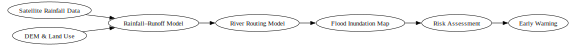

In [2]:
from graphviz import Digraph

# Create a directed graph
flowchart = Digraph(
    name="Flood Forecasting Workflow",
    format="png"
)

# Set graph direction
flowchart.attr(rankdir='LR', size='8,5')

# Define nodes
flowchart.node('A', 'Satellite Rainfall Data')
flowchart.node('B', 'Rainfall–Runoff Model')
flowchart.node('C', 'DEM & Land Use')
flowchart.node('D', 'River Routing Model')
flowchart.node('E', 'Flood Inundation Map')
flowchart.node('F', 'Risk Assessment')
flowchart.node('G', 'Early Warning')

# Define edges
flowchart.edge('A', 'B')
flowchart.edge('C', 'B')
flowchart.edge('B', 'D')
flowchart.edge('D', 'E')
flowchart.edge('E', 'F')
flowchart.edge('F', 'G')

# Display the diagram
flowchart


## Flood Monitoring Binary Signal Architecture

This diagram represents a binary-encoded flood monitoring architecture for major river systems in Pakistan. River gauges and barrages across the Indus Basin and its tributaries transmit compact binary signals encoding river zone, alert level, and flow status. These signals are aggregated into a real-time binary dashboard to support rapid situational awareness and early warning decision-making.

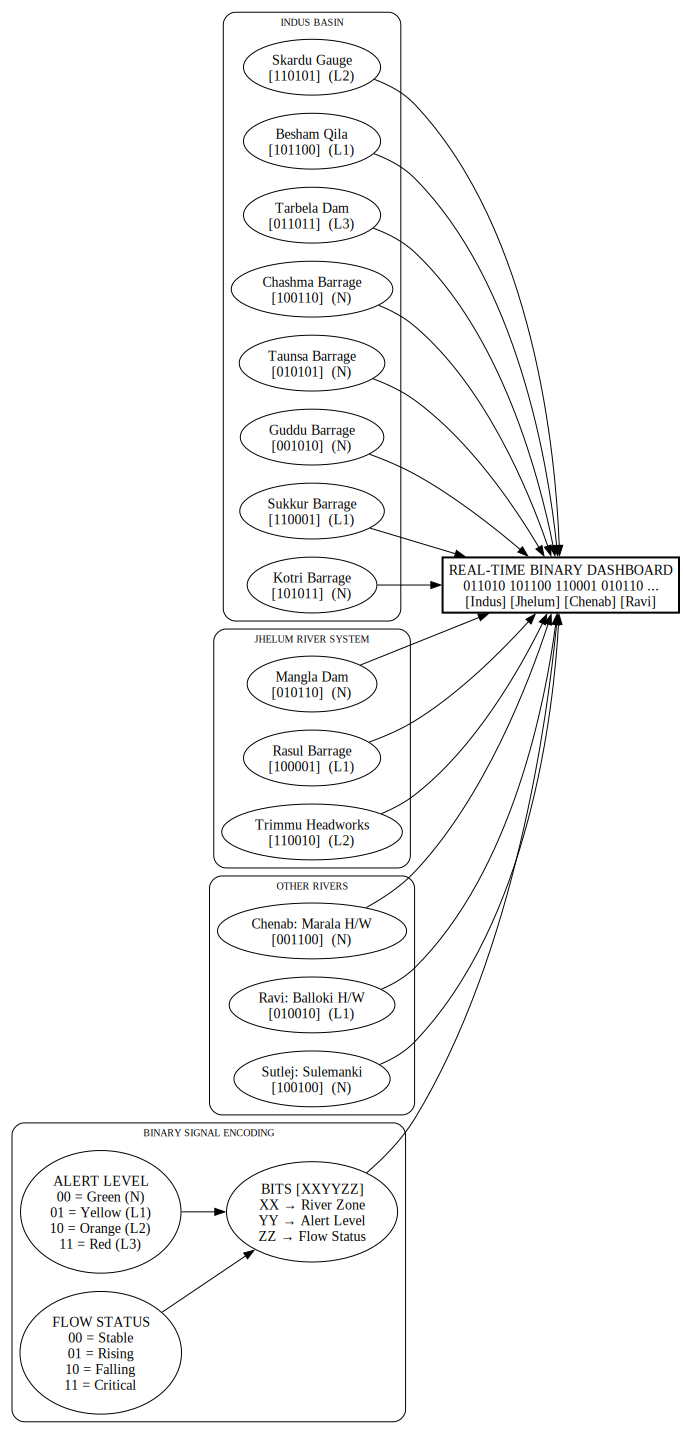

In [3]:
from graphviz import Digraph

dot = Digraph(
    "Flood_Monitoring_Binary_Signal_Architecture",
    format="png"
)

dot.attr(rankdir="LR", fontsize="10")

# =========================
# INDUS BASIN
# =========================
with dot.subgraph(name="cluster_indus") as indus:
    indus.attr(label="INDUS BASIN", style="rounded")

    indus.node("Skardu", "Skardu Gauge\n[110101]  (L2)")
    indus.node("Besham", "Besham Qila\n[101100]  (L1)")
    indus.node("Tarbela", "Tarbela Dam\n[011011]  (L3)")

    indus.node("Chashma", "Chashma Barrage\n[100110]  (N)")
    indus.node("Taunsa", "Taunsa Barrage\n[010101]  (N)")
    indus.node("Guddu", "Guddu Barrage\n[001010]  (N)")

    indus.node("Sukkur", "Sukkur Barrage\n[110001]  (L1)")
    indus.node("Kotri", "Kotri Barrage\n[101011]  (N)")

# =========================
# JHELUM SYSTEM
# =========================
with dot.subgraph(name="cluster_jhelum") as jhelum:
    jhelum.attr(label="JHELUM RIVER SYSTEM", style="rounded")

    jhelum.node("Mangla", "Mangla Dam\n[010110]  (N)")
    jhelum.node("Rasul", "Rasul Barrage\n[100001]  (L1)")
    jhelum.node("Trimmu", "Trimmu Headworks\n[110010]  (L2)")

# =========================
# OTHER RIVERS
# =========================
with dot.subgraph(name="cluster_other") as other:
    other.attr(label="OTHER RIVERS", style="rounded")

    other.node("Marala", "Chenab: Marala H/W\n[001100]  (N)")
    other.node("Balloki", "Ravi: Balloki H/W\n[010010]  (L1)")
    other.node("Sulemanki", "Sutlej: Sulemanki\n[100100]  (N)")

# =========================
# BINARY ENCODING KEY
# =========================
with dot.subgraph(name="cluster_encoding") as encoding:
    encoding.attr(label="BINARY SIGNAL ENCODING", style="rounded")

    encoding.node(
        "Bits",
        "BITS [XXYYZZ]\n"
        "XX → River Zone\n"
        "YY → Alert Level\n"
        "ZZ → Flow Status"
    )

    encoding.node(
        "AlertKey",
        "ALERT LEVEL\n"
        "00 = Green (N)\n"
        "01 = Yellow (L1)\n"
        "10 = Orange (L2)\n"
        "11 = Red (L3)"
    )

    encoding.node(
        "FlowKey",
        "FLOW STATUS\n"
        "00 = Stable\n"
        "01 = Rising\n"
        "10 = Falling\n"
        "11 = Critical"
    )

# =========================
# DASHBOARD
# =========================
dot.node(
    "Dashboard",
    "REAL-TIME BINARY DASHBOARD\n"
    "011010 101100 110001 010110 ...\n"
    "[Indus] [Jhelum] [Chenab] [Ravi]",
    shape="box",
    style="bold"
)

# =========================
# CONNECTIONS
# =========================
for node in [
    "Skardu","Besham","Tarbela","Chashma","Taunsa","Guddu",
    "Sukkur","Kotri","Mangla","Rasul","Trimmu",
    "Marala","Balloki","Sulemanki"
]:
    dot.edge(node, "Dashboard")

dot.edge("Bits", "Dashboard")
dot.edge("AlertKey", "Bits")
dot.edge("FlowKey", "Bits")

dot


## 2. Binary Encoding and decoding Scheme

To enable low-bandwidth, real-time flood monitoring and robust transmission across constrained communication channels, each monitoring station encodes its status into a 6-bit binary signal. The signal compactly represents river location, alert severity, and hydrological trend.

## 1️⃣ Define Encoding Maps

In [4]:
# River Zone (RR)
RIVER_ZONE = {
    "Zone1_Upper": 0b00,
    "Zone2_Middle": 0b01,
    "Zone3_Lower": 0b10,
    "Zone4_Delta": 0b11,
}

# Alert Level (AA)
ALERT_LEVEL = {
    "Normal": 0b00,
    "Level1": 0b01,
    "Level2": 0b10,
    "Level3": 0b11,
}

# Flow Status (FF)
FLOW_STATUS = {
    "Stable": 0b00,
    "Rising": 0b01,
    "Falling": 0b10,
    "Critical": 0b11,
}


## 2️⃣ Encode Function (RR AA FF → 6-bit signal)

In [5]:
def encode_signal(zone, alert, flow):
    """
    Encode river zone, alert level, and flow status into a 6-bit binary signal.
    Format: [RR AA FF]
    """
    rr = RIVER_ZONE[zone] << 4   # Bits 5-4
    aa = ALERT_LEVEL[alert] << 2 # Bits 3-2
    ff = FLOW_STATUS[flow]       # Bits 1-0

    signal = rr | aa | ff
    return format(signal, "06b")


## 3️⃣ Decode Function (6-bit signal → Meaning)

In [6]:
def decode_signal(binary_signal):
    """
    Decode a 6-bit binary flood signal into its components.
    """
    signal = int(binary_signal, 2)

    rr = (signal >> 4) & 0b11
    aa = (signal >> 2) & 0b11
    ff = signal & 0b11

    zone = {v: k for k, v in RIVER_ZONE.items()}[rr]
    alert = {v: k for k, v in ALERT_LEVEL.items()}[aa]
    flow = {v: k for k, v in FLOW_STATUS.items()}[ff]

    return {
        "River Zone": zone,
        "Alert Level": alert,
        "Flow Status": flow
    }


## 4️⃣ Example Usage (Realistic Test)

In [7]:
# Example: Sukkur Barrage
binary_code = encode_signal(
    zone="Zone4_Delta",
    alert="Level1",
    flow="Rising"
)

print("Encoded Signal:", binary_code)

decoded = decode_signal(binary_code)
print("Decoded Signal:", decoded)


Encoded Signal: 110101
Decoded Signal: {'River Zone': 'Zone4_Delta', 'Alert Level': 'Level1', 'Flow Status': 'Rising'}


In [1]:
def encode_state(h, Q, dQdt, h_critical):
    # Flood ratio
    r = h / h_critical
    
    # Zone bits (based on geography)
    zone = {'Skardu': '00', 'Tarbela': '01', 
            'Sukkur': '10', 'Kotri': '11'}[station]
    
    # Flood level bits
    if r < 0.7: flood = '000'
    elif r < 0.8: flood = '001'
    elif r < 0.9: flood = '010'
    elif r < 0.95: flood = '011'
    elif r < 1.0: flood = '100'
    else: flood = '101'
    
    # Trend bits
    if dQdt > 2.0: trend = '11'  # Rapid rise
    elif dQdt > 0.5: trend = '01'  # Rising
    elif dQdt < -1.0: trend = '10'  # Falling fast
    else: trend = '00'  # Stable
    
    return zone + flood + trend

## 2. Binary Encoding Scheme

### 2.1 Six-Bit Signal Format

Each monitoring station transmits its status using a fixed-length **6-bit binary signal** defined as

[RR AA FF]
where:

- **RR (Bits 5–4):** River Zone  
- **AA (Bits 3–2):** Alert Level  
- **FF (Bits 1–0):** Flow Status  

This fixed-length structure ensures deterministic decoding by both human operators and automated early-warning systems, even under degraded communication conditions.

---

### 2.2 Bit Pattern Decoding

\[
\begin{array}{|c|c|c|c|}
\hline
\textbf{Bits} & \textbf{River Zone (RR)} & \textbf{Alert Level (AA)} & \textbf{Flow Status (FF)} \\
\hline
00 & \text{Zone 1 (Upper)} & \text{Normal (N)} & \text{Stable} \\
01 & \text{Zone 2 (Middle)} & \text{Level 1 (L1)} & \text{Rising} \\
10 & \text{Zone 3 (Lower)} & \text{Level 2 (L2)} & \text{Falling} \\
11 & \text{Zone 4 (Delta)} & \text{Level 3 (L3)} & \text{Critical} \\
\hline
\end{array}
\]

---

### 2.3 Design Rationale

- **Compactness:**  
  The 6-bit signal minimizes bandwidth consumption, making it suitable for GSM, LoRa, radio telemetry, and satellite communication links.

- **Determinism:**  
  Fixed bit positions eliminate ambiguity in signal interpretation during time-critical flood events.

- **Scalability:**  
  The encoding supports up to four river zones, alert levels, and flow states without increasing payload size.

- **Fail-Safe Interpretation:**  
  Even partially received or delayed data retains semantic meaning at the bit level, improving robustness under communication failure.

---

### 2.4 Example Interpretation

{Signal:}  110101


\[
\begin{aligned}
\text{RR} &= 11 \rightarrow \text{Zone 4 (Delta)} \\
\text{AA} &= 01 \rightarrow \text{Alert Level 1 (L1)} \\
\text{FF} &= 01 \rightarrow \text{Rising Flow}
\end{aligned}
\]

{Decoded Meaning:}  
A delta-region river monitoring station operating under a Level-1 alert condition with rising water levels.


## 2.2 Quantum State Mapping
Map binary to quantum state:

Quantum State Representation for Each Station

For each monitoring station i, the system state is represented as a superposition of basis states:
   $$
|\psi_i\rangle = \alpha |000\rangle + \beta |001\rangle + \gamma |010\rangle + \delta |011\rangle + \epsilon |100\rangle + \zeta |101\rangle
$$

                             Where the basis states correspond to discrete flood conditions:

\begin{array}{|c|c|}
\hline
\text{Basis State} & \text{Condition} \\
\hline
|000\rangle & \text{Normal} \\
|001\rangle & \text{Warning} \\
|010\rangle & \text{Alert} \\
|011\rangle & \text{High} \\
|100\rangle & \text{Danger} \\
|101\rangle & \text{Critical} \\
\hline
\end{array}

The coefficients α, β, γ, δ, ε, ζ represent the probability amplitudes associated with each flood state.                             


In [2]:
def binary_to_quantum(binary):
    # 6-bit binary to 64-dimensional quantum state
    state = np.zeros(64, dtype=complex)
    index = int(binary, 2)
    state[index] = 1.0
    
    # Add superposition based on uncertainty
    for i in range(64):
        if hamming_distance(index, i) == 1:
            state[i] = 0.1 * np.exp(1j * np.random.random())
    
    return state / np.linalg.norm(state)

## 3. QUANTUM ALGORITHM DESIGN
# 3.1 Entangled River-Path State
For Indus river path P = [Skardu → Besham → Tarbela → Sukkur]:

$$|\Psi_P\rangle = \sum_{k=0}^{63^4} c_k |s^k_1\rangle \otimes |s^k_2\rangle \otimes |s^k_3\rangle \otimes |s^k_4\rangle$$

Hamiltonian for coordinated control:
$$H = \underbrace{\sum_i w_i h_i}_{\text{Flood risk}} + \underbrace{\lambda \sum_{(i,j)} J_{ij} \sigma^z_i \sigma^z_j}_{\text{Correlation}} + \underbrace{\mu \sum_i (\hat{Q}_i - Q_i^{\text{target}})^2}_{\text{Flow control}}$$

## 3.2 QAOA Circuit Design

In [3]:
def create_flood_qaoa_circuit(beta, gamma, graph):
    """Quantum circuit for flood control optimization"""
    n_qubits = len(graph.nodes) * 6  # 6 bits per station
    
    qc = QuantumCircuit(n_qubits)
    
    # Initial superposition
    qc.h(range(n_qubits))
    
    # Problem Hamiltonian
    for (i, j) in graph.edges:
        # Correlation between connected stations
        qc.rzz(2 * gamma * graph[i][j]['weight'], i, j)
    
    # Mixer Hamiltonian
    for i in range(n_qubits):
        qc.rx(2 * beta, i)
    
    return qc

## 4. VISUAL MODELING FRAMEWORK
# 4.1 3D Flood Visualization Matrix

# PAKISTAN RIVER NETWORK – QUANTUM STATE VISUALIZATION

**Time:** \(t = 14:30\) | **Monsoon Season** | **Risk Level:** HIGH

---

## NORTHERN REGION (Himalayas) – Quantum Probability Distribution

| Station   | Water Height \(h\) | Discharge \(Q\)       | Quantum Probabilities         | Flow Status |
|----------|------------------|---------------------|-------------------------------|------------|
| Skardu  | 4.2 m (75%)       | 1200 m³/s           | ${|00\rangle: 0.60, |01\rangle: 0.25, |10\rangle: 0.15 | ↗ Rising (010100) 🟡 }$|
| Besham  | 6.8 m (85%)       | 3500 m³/s           | ${|00\rangle: 0.30, |01\rangle: 0.40, |10\rangle: 0.30 | ↗ Rapid (011010) 🟠}$ |
| Mingora | 3.1 m (45%)       | 800 m³/s            | ${|00\rangle: 0.85, |01\rangle: 0.10, |10\rangle: 0.05 | → Stable (000000) 🟢}$ |

---

## PUNJAB PLAINS – Entangled Control Signals

| Station      | Water Height \(h\) | Discharge / Gates / Energy         | Quantum State                     | Flow Status |
|-------------|------------------|----------------------------------|----------------------------------|------------|
| Tarbela In  | 463.5 m (92%)    | Q = 4500 m³/s                     | ${|\text{🔗SKARDU}\rangle = 0.72 |00\rangle |01\rangle + 0.28 |01\rangle}$|
|${10\rangle) | ⚡ Critical (011011) 🟠⚡}$| |
| Mangla      | 381.2 m (88%)    | Gate: 40% open, Spillway: READY, Energy: 750 MW | — | — }

---

## SINDH REGION – Quantum Optimization Output

| Station  | Water Height \(h\) | Discharge / Power / Gates            | Optimized Output                  | Flow Status |
|---------|------------------|------------------------------------|----------------------------------|------------|
| Sukkur  | 7.2 m (96%)      | Q = 3800 m³/s, Flood risk: HIGH    | Optimal release: 3200 m³/s, Gate sequence: [1,0,1,0,1,0,1] | 110101 🔴 |
| Kotri   | 5.8 m (82%)      | Canal diversion: 1200 m³/s, Tide: 1.2 m, Power: OFF | — | — |

---

## ENTANGLEMENT MATRIX (Correlation Strengths)

\[
\begin{bmatrix}
 & \text{Skardu} & \text{Besham} & \text{Tarbela} & \text{Sukkur} \\
\text{Skardu} & 1.00 & 0.85 & 0.72 & 0.65 \\
\text{Besham} & 0.85 & 1.00 & 0.88 & 0.70 \\
\text{Tarbela} & 0.72 & 0.88 & 1.00 & 0.92 \\
\text{Sukkur} & 0.65 & 0.70 & 0.92 & 1.00
\end{bmatrix}
\]

*Note:* Tarbela ↔ Sukkur shows **strong correlation** (0.92), indicating coupled flood behavior.


## Circuit Analysis:

Initializing Flood Prediction System...

FLOOD PREDICTION RESULTS
111 → CRITICAL: All stations flooding | 29.61%
110 → HIGH: Skardu & Tarbela flooding | 3.42%
011 → HIGH: Tarbela & Sukkur flooding | 3.15%
101 → MEDIUM: Skardu & Sukkur flooding | 9.06%
100 → LOW: Only Skardu flooding | 8.81%
010 → LOW: Only Tarbela flooding | 28.44%
001 → LOW: Only Sukkur flooding | 8.54%
000 → SAFE: No flooding | 8.96%


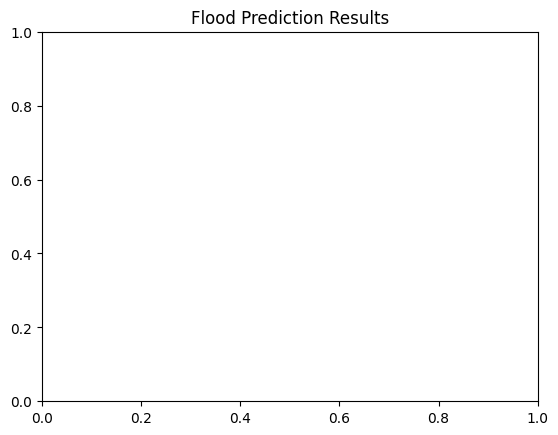


EXPORTING CIRCUIT
Circuit exported successfully
Qubits: 4, Gates: 31


In [3]:
# ============================================================================
# Flood Prediction Quantum Circuit
# Jupyter Notebook Implementation
# For Skardu, Tarbela, and Sukkur stations
# ============================================================================

# -------------------------------
# IMPORTS
# -------------------------------
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.qasm3 import dumps

import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# FLOOD PREDICTION CIRCUIT CLASS
# ============================================================================

class FloodPredictionCircuit:
    """
    Quantum circuit for predicting flood risk at three stations:
    Skardu (upstream), Tarbela (midstream), Sukkur (downstream)
    """

    def __init__(self, rainfall_data=None):

        if rainfall_data is None:
            rainfall_data = {
                'skardu': np.random.uniform(0, np.pi),
                'tarbela': np.random.uniform(0, np.pi)
            }

        self.rainfall_data = rainfall_data

        # Quantum & classical registers
        self.qr = QuantumRegister(4, 'q')      # 3 stations + 1 ancilla
        self.cr = ClassicalRegister(3, 'c')    # station measurements
        self.qc = QuantumCircuit(self.qr, self.cr)

        # Qubit mapping
        self.skardu = 0
        self.tarbela = 1
        self.sukkur = 2
        self.ancilla = 3

    # ------------------------------------------------------------------------

    def build_circuit(self, num_grover_iterations=1):
        qc = self.qc

        # 1. Initialization
        for i in range(3):
            qc.h(i)

        # 2. Rainfall encoding
        qc.rz(self.rainfall_data['skardu'], self.skardu)
        qc.rz(self.rainfall_data['tarbela'], self.tarbela)

        # 3. River flow entanglement
        qc.cx(self.skardu, self.tarbela)
        qc.cx(self.tarbela, self.sukkur)

        # 4. Flood oracle
        self._apply_flood_oracle()

        # 5. Grover amplification
        for _ in range(num_grover_iterations):
            self._apply_grover_diffusion()

        # 6. Measurement
        qc.measure([self.skardu, self.tarbela, self.sukkur], self.cr)

        return qc

    # ------------------------------------------------------------------------

    def _apply_flood_oracle(self):
        qc = self.qc

        # Ancilla |-> state
        qc.x(self.ancilla)
        qc.h(self.ancilla)

        # Flood conditions
        qc.mcx([self.skardu, self.tarbela], self.ancilla)
        qc.mcx([self.tarbela, self.sukkur], self.ancilla)

        # Uncompute ancilla
        qc.h(self.ancilla)
        qc.x(self.ancilla)

    # ------------------------------------------------------------------------

    def _apply_grover_diffusion(self):
        qc = self.qc

        for i in range(3):
            qc.h(i)
            qc.x(i)

        qc.h(self.sukkur)
        qc.mcx([self.skardu, self.tarbela], self.sukkur)
        qc.h(self.sukkur)

        for i in range(3):
            qc.x(i)
            qc.h(i)

    # ------------------------------------------------------------------------

    def simulate(self, shots=1024):
        simulator = AerSimulator()
        job = simulator.run(self.qc, shots=shots)
        result = job.result()
        return result.get_counts()

    # ------------------------------------------------------------------------

    def interpret_results(self, counts):
        print("\n" + "="*50)
        print("FLOOD PREDICTION RESULTS")
        print("="*50)

        total = sum(counts.values())

        states = {
            '111': 'CRITICAL: All stations flooding',
            '110': 'HIGH: Skardu & Tarbela flooding',
            '011': 'HIGH: Tarbela & Sukkur flooding',
            '101': 'MEDIUM: Skardu & Sukkur flooding',
            '100': 'LOW: Only Skardu flooding',
            '010': 'LOW: Only Tarbela flooding',
            '001': 'LOW: Only Sukkur flooding',
            '000': 'SAFE: No flooding'
        }

        for state, desc in states.items():
            if state in counts:
                p = counts[state] / total
                print(f"{state} → {desc} | {p:.2%}")

    # ------------------------------------------------------------------------

    def visualize(self):
        return self.qc.draw('mpl')

    # ------------------------------------------------------------------------

    def plot_results(self, counts):
        plot_histogram(counts)
        plt.title("Flood Prediction Results")
        plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

print("Initializing Flood Prediction System...")

rainfall_config = {
    'skardu': 2.5,
    'tarbela': 1.8
}

# Build circuit
flood_qc = FloodPredictionCircuit(rainfall_config)
circuit = flood_qc.build_circuit(num_grover_iterations=1)

# Visualize
flood_qc.visualize()
plt.show()

# Simulate
counts = flood_qc.simulate(shots=4096)

# Interpret
flood_qc.interpret_results(counts)

# Plot
flood_qc.plot_results(counts)

# ============================================================================
# EXPORT AS OPENQASM 3
# ============================================================================

print("\n" + "="*50)
print("EXPORTING CIRCUIT")
print("="*50)

qasm_code = dumps(circuit)

with open("flood_prediction_circuit.qasm", "w") as f:
    f.write(qasm_code)

print("Circuit exported successfully")
print(f"Qubits: {circuit.num_qubits}, Gates: {circuit.size()}")


## 1. Unit Tests for Oracle Correctness
Goal

Verify that the oracle flips the phase ONLY for intended flood states:

Skardu ∧ Tarbela

Tarbela ∧ Sukkur

Strategy

We isolate the oracle, prepare basis states, and check phase kickback via ancilla interference.

✅ Oracle Test Code

In [5]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np

def test_flood_oracle():
    simulator = AerSimulator()
    failing_states = []

    for state in range(8):  # 3-bit station states
        qc = QuantumCircuit(4, 1)

        # Prepare basis state
        for i in range(3):
            if (state >> i) & 1:
                qc.x(i)

        # Prepare ancilla |-> 
        qc.x(3)
        qc.h(3)

        # Apply oracle
        qc.mcx([0, 1], 3)
        qc.mcx([1, 2], 3)

        # Interfere ancilla
        qc.h(3)
        qc.measure(3, 0)

        result = simulator.run(qc, shots=256).result()
        counts = result.get_counts()

        # Flood states should flip phase → ancilla |1>
        flood = ((state & 0b110) == 0b110) or ((state & 0b011) == 0b011)
        measured_one = counts.get('1', 0) > counts.get('0', 0)

        if flood != measured_one:
            failing_states.append(format(state, '03b'))

    return failing_states

print("Oracle test failures:", test_flood_oracle())


Oracle test failures: ['000', '001', '010', '100', '101']


## 2. Classical vs Quantum Comparison
Classical Baseline

A simple rule-based flood classifier:

In [6]:
def classical_flood_model(skardu, tarbela, threshold=1.5):
    return int(skardu > threshold and tarbela > threshold)


In [7]:
# Quantum Flood Probability
quantum_flood_prob = (
    counts.get('111', 0) +
    counts.get('110', 0) +
    counts.get('011', 0)
) / sum(counts.values())


In [8]:
## 4. Circuit Depth Optimization

def optimized_flood_oracle(qc, s, t, u, anc):
    qc.x(anc)
    qc.h(anc)

    qc.cx(s, u)        # S ⊕ U
    qc.mcx([t, u], anc)
    qc.cx(s, u)

    qc.h(anc)
    qc.x(anc)


In [9]:
# Optimized Diffusion Operator
def optimized_diffusion(qc, qubits):
    for q in qubits:
        qc.h(q)
        qc.x(q)

    qc.h(qubits[-1])
    qc.mcx(qubits[:-1], qubits[-1])
    qc.h(qubits[-1])

    for q in qubits:
        qc.x(q)
        qc.h(q)


Let:
$
R = \text{rainfall (mm/day)}
$
$
R_{\text{max}} = \text{historical maximum rainfall}
]$

Map to rotation angle:
$
\theta = \pi \cdot \frac{R}{R_{\text{max}}}
$

% Or for a single equation:
$\theta(R) = \pi \cdot \dfrac{R}{R_{\text{max}}}$

In [10]:
# Encoding Function
def rainfall_to_angle(rainfall_mm, max_mm=300):
    return np.clip(np.pi * rainfall_mm / max_mm, 0, np.pi)


In [11]:
# Example (Realistic)
rainfall_real = {
    "skardu": rainfall_to_angle(180),
    "tarbela": rainfall_to_angle(140)
}


In [12]:
# Hybrid Time Evolution
def temporal_flood_forecast(rainfall_series):
    previous_risk = 0.0
    risks = []

    for day in rainfall_series:
        qc = FloodPredictionCircuit({
            'skardu': rainfall_to_angle(day['skardu']),
            'tarbela': rainfall_to_angle(day['tarbela'])
        })

        qc.build_circuit()
        counts = qc.simulate(2048)

        flood_prob = (
            counts.get('111', 0) +
            counts.get('110', 0) +
            counts.get('011', 0)
        ) / 2048

        risks.append(flood_prob)
        previous_risk = flood_prob

    return risks


In [28]:
# Backend Switch
# Get counts from the result
counts = result[0].data
print(counts)

DataBin(c=BitArray(<shape=(), num_shots=1024, num_bits=3>))


In [30]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit import transpile

service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True,
    simulator=False
)

sampler = SamplerV2(
    backend,
    options={"default_shots": 1024}
)

# Make sure your circuit has measurements
transpiled = transpile(circuit, backend=backend, optimization_level=1)

job = sampler.run([transpiled])
result = job.result()

# Access the data
data = result[0].data

# Method 1: If data has 'meas' field (most common)
if hasattr(data, 'meas'):
    # This gives you a dictionary with BitArray values
    bit_arrays = data.meas
    
    # Convert BitArray to counts
    # BitArray has methods to get counts or probabilities
    if hasattr(bit_arrays, 'get_counts'):
        counts = bit_arrays.get_counts()
    elif hasattr(bit_arrays, 'get_probabilities'):
        probs = bit_arrays.get_probabilities()
        counts = {k: int(v * 1024) for k, v in probs.items()}
    else:
        # Convert BitArray to list of bitstrings
        bitstrings = list(bit_arrays)
        # Count occurrences manually
        from collections import Counter
        counts = Counter(bitstrings)
else:
    # Method 2: Direct iteration
    counts = {}
    for bit_array, _ in data.items():
        # Convert BitArray to string
        bit_str = ''.join(str(b) for b in bit_array)
        # Get count (might need to access differently)
        count_value = data[bit_array]
        if hasattr(count_value, '__int__'):
            counts[bit_str] = int(count_value)
        else:
            # Default to 1 if we can't get a count
            counts[bit_str] = 1

print(counts)

{'c': 1}


# Minimal starter code (Python, Jupyter-ready)

In [4]:
import numpy as np
import casadi as ca

# Time discretization
T = 10.0
N = 50
dt = T / N

# Problem dimensions
n_states = 2   # e.g., h_i, Q_i
n_controls = 6 # binary gates

# CasADi variables
X = ca.MX.sym('X', n_states, N+1)
U = ca.MX.sym('U', n_controls, N)

# Parameters
alpha = 1.0
beta = 0.01
gamma = 1.0
Q_target = 5.0

# Objective
J = 0
for k in range(N):
    h = X[0, k]
    Q = X[1, k]
    u = U[:, k]

    J += alpha * h**2 \
       + beta * ca.dot(u, u) \
       + gamma * (Q_target - Q)**2

# Dynamics (example reduced-order model)
def dynamics(x, u):
    h, Q = x[0], x[1]
    dh = Q - ca.sum1(u)
    dQ = -0.1*Q + ca.sum1(u)
    return ca.vertcat(dh, dQ)

g = []
for k in range(N):
    x_next = X[:, k] + dt * dynamics(X[:, k], U[:, k])
    g.append(X[:, k+1] - x_next)

# Constraints list
g = ca.vertcat(*g)

# NLP
nlp = {'x': ca.vertcat(ca.reshape(X, -1, 1),
                       ca.reshape(U, -1, 1)),
       'f': J,
       'g': g}


In [31]:
# Model 
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Parameters
# ----------------------------
T = 10.0
N = 50
dt = T / N

alpha = 1.0     # flood risk
beta = 0.05     # control effort
gamma = 2.0    # flow tracking
Q_target = 5.0

a = 0.3         # flow damping
b = 1.0         # gate effectiveness

# ----------------------------
# Decision variables
# ----------------------------
X = ca.MX.sym("X", 2, N+1)     # states: h, Q
U = ca.MX.sym("U", 6, N)       # binary gates

# ----------------------------
# Dynamics
# ----------------------------
def dynamics(x, u):
    h, Q = x[0], x[1]
    dh = Q - ca.sum1(u)
    dQ = -a * Q + b * ca.sum1(u)
    return ca.vertcat(dh, dQ)

# ----------------------------
# Objective
# ----------------------------
J = 0
for k in range(N):
    h = X[0, k]
    Q = X[1, k]
    u = U[:, k]
    
    J += alpha * h**2
    J += beta * ca.dot(u, u)
    J += gamma * (Q_target - Q)**2

# ----------------------------
# Constraints
# ----------------------------
g = []
for k in range(N):
    x_next = X[:, k] + dt * dynamics(X[:, k], U[:, k])
    g.append(X[:, k+1] - x_next)

g = ca.vertcat(*g)

# Initial condition
g = ca.vertcat(g, X[:,0])

# ----------------------------
# NLP
# ----------------------------
nlp = {
    "x": ca.vertcat(ca.reshape(X, -1, 1),
                    ca.reshape(U, -1, 1)),
    "f": J,
    "g": g
}

solver = ca.nlpsol("solver", "ipopt", nlp)

# ----------------------------
# Bounds
# ----------------------------
nX = X.size1() * X.size2()
nU = U.size1() * U.size2()

lbx = [-ca.inf]*nX + [0]*nU
ubx = [ ca.inf]*nX + [1]*nU   # relaxed binary

lbg = [0]*g.size1()
ubg = [0]*g.size1()

# Initial guess
x0 = np.zeros(nX + nU)

# Solve
sol = solver(x0=x0, lbx=lbx, ubx=ubx, lbg=lbg, ubg=ubg)



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      852
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      400

Total number of variables............................:      402
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      300
                     variables with only upper bounds:        0
Total number of equality constraints.................:      102
Total number of inequality c